# Matplotlib — Plotting Fundamentals

A plot is just numbers drawn on axes. Matplotlib gives you full manual control: you create a figure, add axes, and draw whatever you want. Stick with the `plt` (pyplot) interface until you need something fancy.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

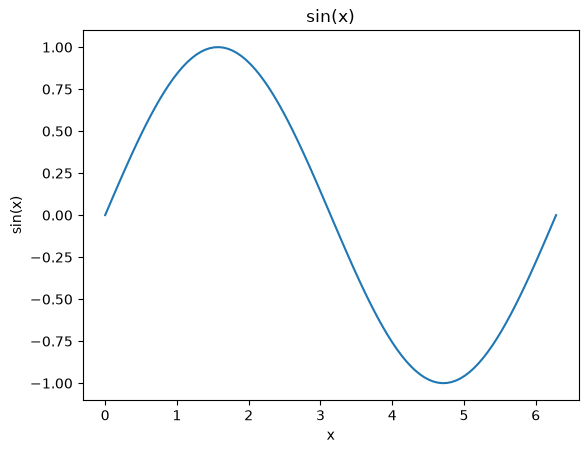

In [2]:
## line plot: the default
xs = np.linspace(0, 2 * np.pi, 100)
ys = np.sin(xs)

plt.plot(xs, ys)
plt.title('sin(x)')
plt.xlabel('x')
plt.ylabel('sin(x)')
plt.show()

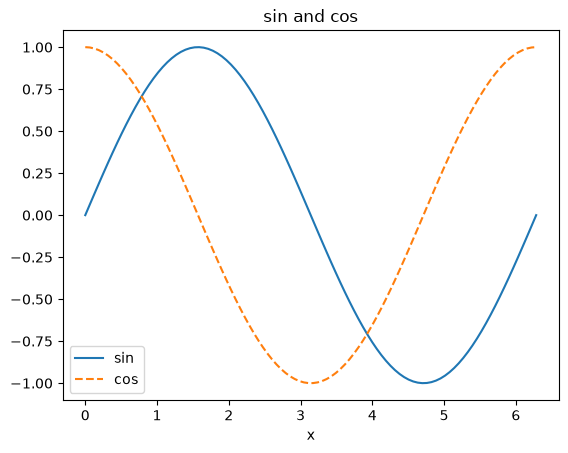

In [3]:
## several series on the same axes
plt.plot(xs, np.sin(xs), label='sin')
plt.plot(xs, np.cos(xs), '--', label='cos')   # '--' is a dashed line
plt.title('sin and cos')
plt.xlabel('x')
plt.legend()
plt.show()

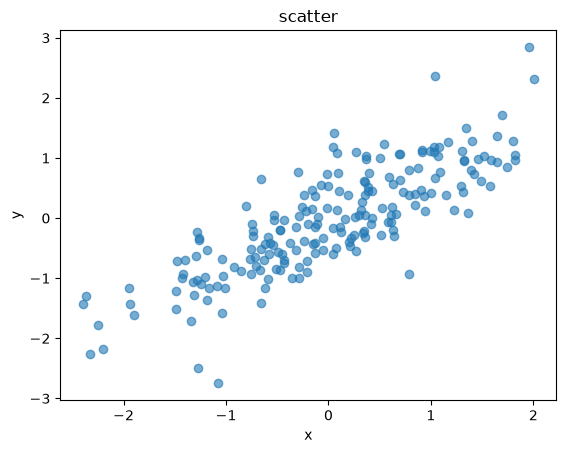

In [4]:
## scatter: relationship between two variables
rng = np.random.default_rng(0)
x = rng.normal(size=200)
y = x * 0.8 + rng.normal(size=200) * 0.5

plt.scatter(x, y, alpha=0.6)   # alpha = transparency
plt.title('scatter')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

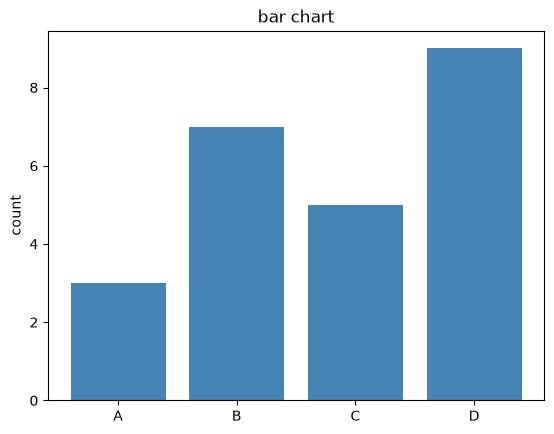

In [5]:
## bar: compare categories
labels = ['A', 'B', 'C', 'D']
values = [3, 7, 5, 9]

plt.bar(labels, values, color='steelblue')
plt.title('bar chart')
plt.ylabel('count')
plt.show()

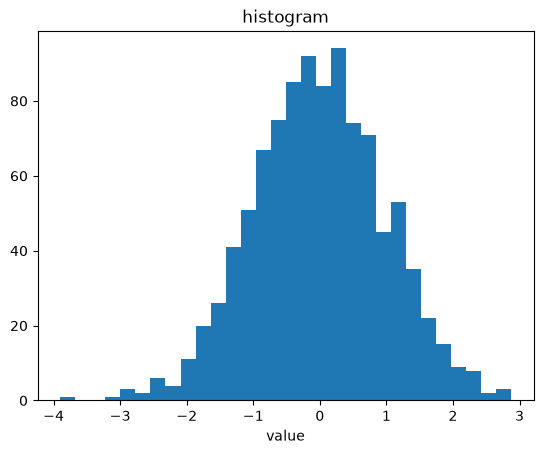

In [6]:
## histogram: distribution of one variable
samples = rng.normal(size=1000)

plt.hist(samples, bins=30)
plt.title('histogram')
plt.xlabel('value')
plt.show()

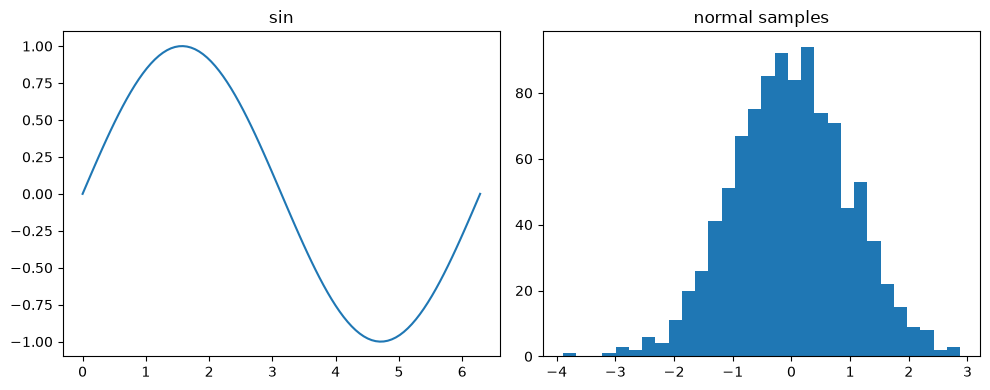

In [7]:
## several plots side by side
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].plot(xs, np.sin(xs))
axs[0].set_title('sin')

axs[1].hist(samples, bins=30)
axs[1].set_title('normal samples')

fig.tight_layout()
plt.show()

## Plotting real data

Numbers on axes are only interesting once they answer a question. Here we plot `../data/sales_data_sample.csv` (orders from a scale-model retailer) to see what sells, when, and how much.

In [8]:
import pandas as pd

sales = pd.read_csv('../data/sales_data_sample.csv', encoding='cp1251')
print(sales.shape)
sales[['PRODUCTLINE', 'COUNTRY', 'YEAR_ID', 'SALES']].head()

(2823, 25)


,PRODUCTLINE,COUNTRY,YEAR_ID,SALES
0,Motorcycles,USA,2003,2871.00
1,Motorcycles,France,2003,2765.90
2,Motorcycles,France,2003,3884.34
3,Motorcycles,USA,2003,3746.70
4,Motorcycles,USA,2003,5205.27


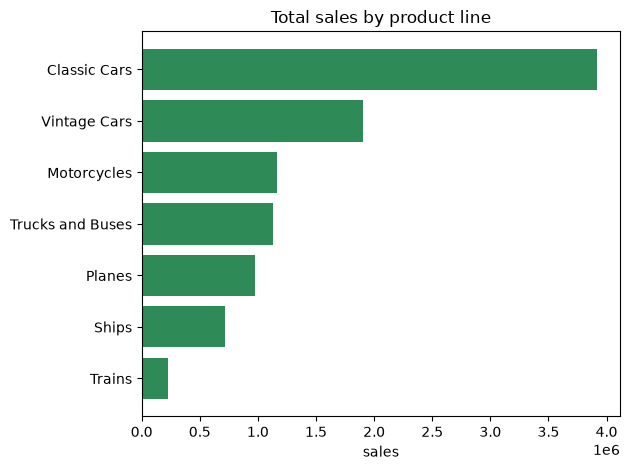

In [9]:
## total sales per product line (horizontal bar reads better for long labels)
by_line = sales.groupby('PRODUCTLINE')['SALES'].sum().sort_values()

plt.barh(by_line.index, by_line.values, color='seagreen')
plt.title('Total sales by product line')
plt.xlabel('sales')
plt.tight_layout()
plt.show()

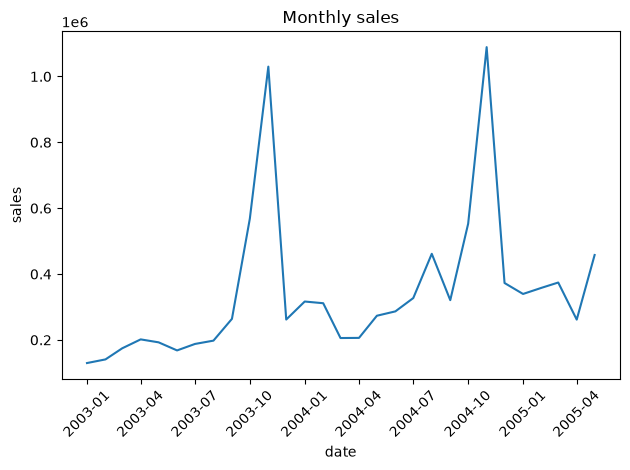

In [10]:
## monthly sales over time
monthly = sales.groupby(['YEAR_ID', 'MONTH_ID'])['SALES'].sum().reset_index()
monthly['date'] = pd.to_datetime(dict(year=monthly.YEAR_ID, month=monthly.MONTH_ID, day=1))

plt.plot(monthly['date'], monthly['SALES'])
plt.title('Monthly sales')
plt.xlabel('date')
plt.ylabel('sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

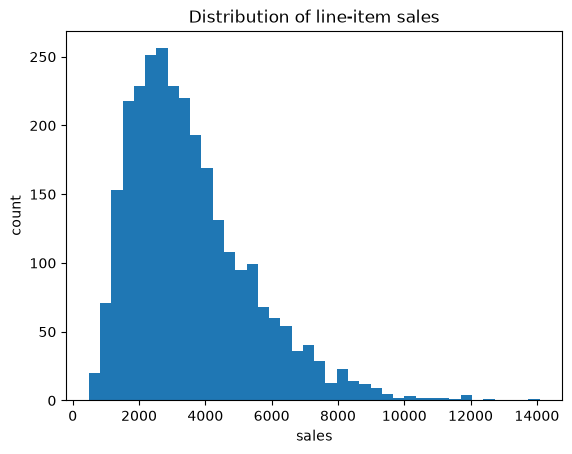

In [11]:
## how are individual line-item sales distributed?
plt.hist(sales['SALES'], bins=40)
plt.title('Distribution of line-item sales')
plt.xlabel('sales')
plt.ylabel('count')
plt.show()

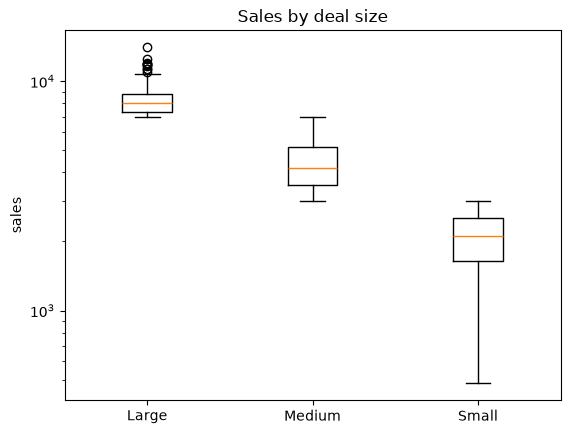

In [12]:
## spread of sales within each deal size
groups = [g['SALES'].values for _, g in sales.groupby('DEALSIZE')]

plt.boxplot(groups, tick_labels=sorted(sales['DEALSIZE'].unique()))
plt.title('Sales by deal size')
plt.ylabel('sales')
plt.yscale('log')   # the values span orders of magnitude
plt.show()